In [25]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, jaccard_score, roc_auc_score, precision_score, recall_score, f1_score

In [26]:
ROOT = Path().resolve()
DATA = ROOT.parent  / "content"

df = pd.read_csv(DATA / "df_exp_50_variable_selection.csv")

In [27]:
df = df.dropna()
print(df.isnull().sum())

customer_country    0
zip_code            0
V14                 0
V4                  0
V12                 0
V10                 0
Amount              0
V28                 0
V26                 0
V11                 0
V3                  0
V13                 0
Class               0
dtype: int64


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   customer_country  500000 non-null  object 
 1   zip_code          500000 non-null  object 
 2   V14               500000 non-null  float64
 3   V4                500000 non-null  float64
 4   V12               500000 non-null  float64
 5   V10               500000 non-null  float64
 6   Amount            500000 non-null  float64
 7   V28               500000 non-null  float64
 8   V26               500000 non-null  float64
 9   V11               500000 non-null  float64
 10  V3                500000 non-null  float64
 11  V13               500000 non-null  float64
 12  Class             500000 non-null  int64  
dtypes: float64(10), int64(1), object(2)
memory usage: 49.6+ MB


In [29]:
df.describe()

,V14,V4,V12,V10,Amount,V28,V26,V11,V3,V13,Class
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,-3.042431,1.952341,-2.708194,-2.406932,105.018968,0.022917,0.018919,1.650463,-2.950189,-0.030489,0.431864
std,4.570602,3.142074,4.456123,4.303260,320.367132,0.458095,0.482678,2.717019,5.784711,1.056417,0.495336
min,-19.247300,-5.683171,-18.713786,-24.624935,-13.889327,-15.430084,-2.604551,-4.797473,-48.325589,-5.791881,0.000000
25%,-5.918571,-0.296234,-4.606188,-3.906205,3.030866,-0.059882,-0.303016,-0.320170,-4.248037,-0.770707,0.000000
50%,-0.649869,1.009074,-0.549027,-0.596756,18.730000,0.027152,-0.022520,0.836044,-1.034135,-0.013393,0.000000
75%,0.201676,3.757295,0.293571,0.092870,97.800322,0.181839,0.316425,3.264031,0.474713,0.695415,1.000000
max,10.526766,16.875344,7.848392,23.745136,25691.160000,33.847808,3.517346,12.056509,9.382558,7.126883,1.000000


In [30]:
# ==============================================================================
# PART 1: ONE-HOT ENCODING (SPARSE) + LOGISTIC REGRESSION
# ==============================================================================
all_results = []

X = df.drop('Class', axis=1)
y = df['Class']

categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object', 'category']).columns.tolist()

# Split before transforming to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Definir el ColumnTransformer
# - Numeric: Apply StandardScaler
# - Categorical: Apply OneHotEncoder
# sparse_output=True because RAM colapses otherwise
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=True, handle_unknown='ignore'), categorical_cols)
    ],
    verbose_feature_names_out=False
)

model_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# Training
model_lr.fit(X_train, y_train)

# Evaluating
y_pred = model_lr.predict(X_test)
y_proba = model_lr.predict_proba(X_test)[:, 1]

all_results.append({
    "Model": "Logistic Regression (Pipeline/Sparse)",
    "AUC": roc_auc_score(y_test, y_proba),
    "Recall": recall_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "Accuracy": accuracy_score(y_test, y_pred)
})


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [31]:
# ==============================================================================
# PART 2: LABEL ENCODING + RANDOM FOREST AND XGBOOST
# ==============================================================================
df_le = df.copy()
le = LabelEncoder()
for col in df_le.columns:
    if df_le[col].dtype == 'object':
        df_le[col] = df_le[col].astype(str)
        df_le[col] = le.fit_transform(df_le[col])

X_le = df_le.drop('Class', axis=1)
y_le = df_le['Class']

X_train_le, X_test_le, y_train_le, y_test_le = train_test_split(
    X_le, y_le, test_size=0.2, random_state=42, stratify=y_le
)

tree_models = {
    "Random Forest (Label Enc)": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost (Label Enc)": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# Training and evaluating
for name, model in tree_models.items():
    model.fit(X_train_le, y_train_le)

    y_pred = model.predict(X_test_le)
    y_proba = model.predict_proba(X_test_le)[:, 1]

    all_results.append({
        "Model": name,
        "AUC": roc_auc_score(y_test_le, y_proba),
        "Recall": recall_score(y_test_le, y_pred),
        "Precision": precision_score(y_test_le, y_pred),
        "F1": f1_score(y_test_le, y_pred),
        "Accuracy": accuracy_score(y_test_le, y_pred)
    })

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:43:38] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,AUC,Recall,Precision,F1,Accuracy
Model,,,,,
Logistic Regression (Pipeline/Sparse),0.999529,0.991247,0.991592,0.991419,0.992590
Random Forest (Label Enc),1.000000,0.999954,0.999861,0.999907,0.999920
XGBoost (Label Enc),0.999990,1.000000,0.999583,0.999792,0.999820


/tmp/ipython-input-3214414671.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df["F1"], palette="viridis")
/tmp/ipython-input-3214414671.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df["Recall"], palette="magma")


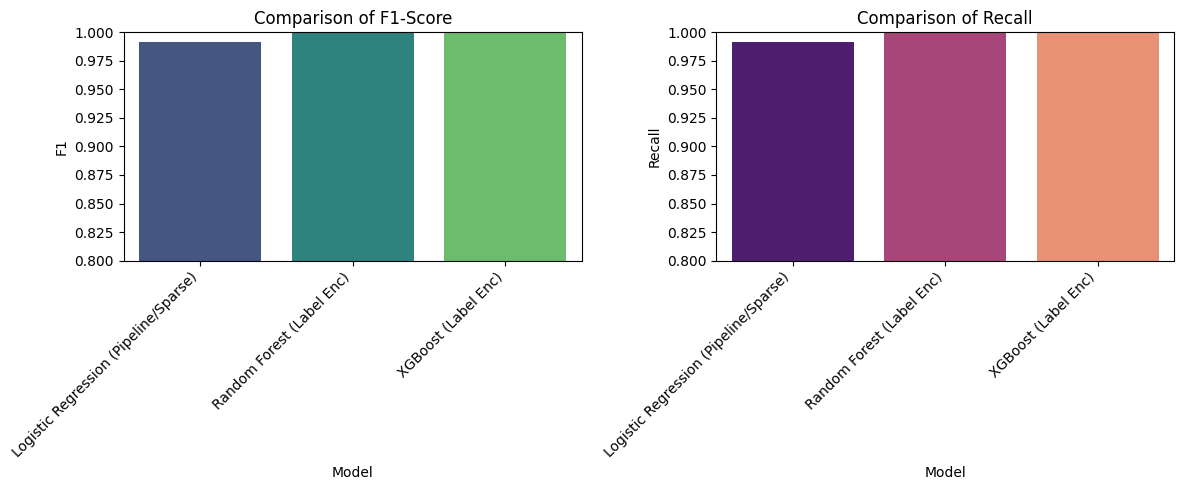

In [32]:

# ==============================================================================
# PART 3: COMPARISON
# ==============================================================================

# df of results
results_df = pd.DataFrame(all_results).set_index("Model")

# table
display(results_df.style.highlight_max(color='lightgreen', axis=0))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(x=results_df.index, y=results_df["F1"], palette="viridis")
plt.title("Comparison of F1-Score")
plt.xticks(rotation=45, ha='right')
plt.ylim(0.8, 1.0)

plt.subplot(1, 2, 2)
sns.barplot(x=results_df.index, y=results_df["Recall"], palette="magma")
plt.title("Comparison of Recall")
plt.xticks(rotation=45, ha='right')
plt.ylim(0.8, 1.0)

plt.tight_layout()
plt.show()